# EDA

In [1]:
# Remove Corrupted images

import os
from PIL import Image

def remove_corrupted_images(folder_path):
    total_chceked = 0
    total_removed = 0

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            total_chceked += 1
            file_path = os.path.join(folder_path, filename)
            try:
                with Image.open(file_path) as img:
                    img.verify()  
            except (IOError, SyntaxError) as e:
                print(f"Removing corrupted image: {file_path} - {e}")
                os.remove(file_path)
                total_removed += 1
    

    print(f"Total images checked: {total_chceked}")
    print(f"Total corrupted images removed: {total_removed}")




In [2]:
dataset_folder = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\Dataset\soil_type_classification\soil_class_images"


In [4]:

def clean_dataset(root_dir):
    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if os.path.isdir(class_path):
            print(f"\nCleaning class: {class_name}")
            remove_corrupted_images(class_path)


clean_dataset(dataset_folder)


Cleaning class: alluvial
Total images checked: 2500
Total corrupted images removed: 0

Cleaning class: desert
Total images checked: 2539
Total corrupted images removed: 0

Cleaning class: mountain
Total images checked: 2500
Total corrupted images removed: 0


In [3]:
# chaeck for duplicate iamges

import hashlib

def file_hash(filepath):
    hasher = hashlib.sha256()
    with open(filepath, "rb") as f:
        while chunk := f.read(8192):
            hasher.update(chunk)
    return hasher.hexdigest()


def remove_duplicates(folder_path):
    hashes = {}
    total_checked = 0
    total_removed = 0

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            total_checked += 1
            file_path = os.path.join(folder_path, filename)
            file_hash_value = file_hash(file_path)

            if file_hash_value in hashes:
                print(f"Removing duplicate image: {file_path} (duplicate of {hashes[file_hash_value]})")
                os.remove(file_path)
                total_removed += 1
            else:
                hashes[file_hash_value] = file_path

    print(f"Total images checked for duplicates: {total_checked}")
    print(f"Total duplicate images removed: {total_removed}")

In [6]:
def clean_duplicates(root_dir):
    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if os.path.isdir(class_path):
            print(f"\nCleaning class: {class_name}")
            remove_duplicates(class_path)


clean_duplicates(dataset_folder)


Cleaning class: alluvial
Removing duplicate image: C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\Dataset\soil_type_classification\soil_class_images\alluvial\alluvial_1.jpg (duplicate of C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\Dataset\soil_type_classification\soil_class_images\alluvial\alluvial_0.jpg)
Removing duplicate image: C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\Dataset\soil_type_classification\soil_class_images\alluvial\alluvial_1015.jpg (duplicate of C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\Dataset\soil_type_classification\soil_class_images\alluvial\alluvial_1014.jpg)
Removing duplicate image: C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\Dataset\soil_type_classification\soil_class_images\alluvial\alluvial_1027.jpg (duplicate of C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\Dataset\soil_type_classification\soil_class_images\alluvial\alluvial_1026.jpg)
Removing duplicate image: C:\

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

def check_distribution(root_dir):
    class_counts = {}

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if os.path.isdir(class_path):
            count = len([
                f 
                for f in os.listdir(class_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif'))
            ])
            class_counts[class_name] = count


    # Convert to a DataFrame for better visualization
    df = pd.DataFrame.from_dict(class_counts, orient='index', columns=['Image_count'])
    df['Percentage'] = (df['Image_count'] / df['Image_count'].sum()) * 100
    print(df)

    #visualize distribution
    df['Image_count'].plot(kind='bar', figsize=(6, 6),color='green')
    plt.title('Number of Images per Class')
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.show()

    #imbalance check
    max_count = df['Image_count'].max()
    min_count = df['Image_count'].min()
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

    print("\n----------Report----------")
    print(f"Total classes: {len(df)}")
    print(f"Total samples: {df['Image_count'].sum()}")
    print(f"Max images in a class: {max_count}")
    print(f"Min images in a class: {min_count}")
    print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")

    if imbalance_ratio > 1.5: print("Warning: class imbalance detected.")
    else: print("Class distribution looks balanced.")



          Image_count  Percentage
alluvial         2472   32.911729
desert           2539   33.803754
mountain         2500   33.284516


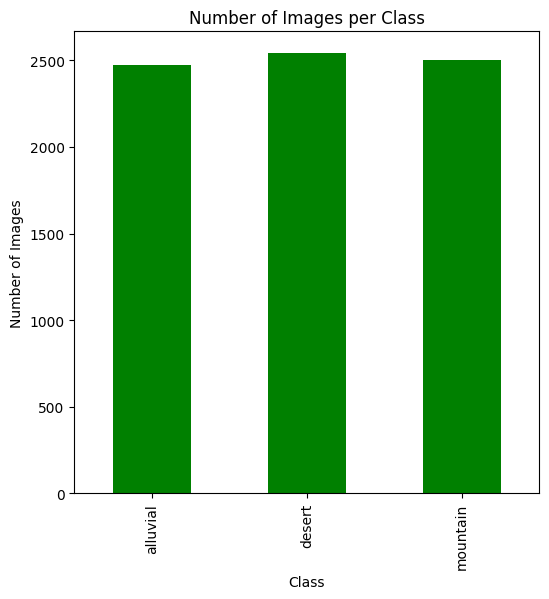


----------Report----------
Total classes: 3
Total samples: 7511
Max images in a class: 2539
Min images in a class: 2472
Imbalance ratio (max/min): 1.03
Class distribution looks balanced.


In [16]:
check_distribution(dataset_folder)

In [13]:
#standardize to rgb image
def standardize_to_rgb(folder_path):
    converted = 0
    checked = 0
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            file_path = os.path.join(folder_path, filename)
            checked += 1

            try:
                with Image.open(file_path) as img:
                    if img.mode != 'RGB':
                        rgb_img = img.convert('RGB')
                        rgb_img.save(file_path)
                        print(f"Converting: {filename} ({img.mode} → RGB)")
                        converted += 1

            except Exception as e:
                print(f"Error processing {file_path}: {e}")
    
    print(f"Total images checked: {checked}")
    print(f"Total images converted to RGB: {converted}")
    


In [14]:
def standardize_ds(root_dir):
    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if os.path.isdir(class_path):
            print(f"\Processing class: {class_name}")
            standardize_to_rgb(class_path)


standardize_ds(dataset_folder)

<>:5: SyntaxWarning: invalid escape sequence '\P'
<>:5: SyntaxWarning: invalid escape sequence '\P'
C:\Users\debas\AppData\Local\Temp\ipykernel_20888\1716592593.py:5: SyntaxWarning: invalid escape sequence '\P'
  print(f"\Processing class: {class_name}")


\Processing class: alluvial
Total images checked: 2472
Total images converted to RGB: 0
\Processing class: desert
Total images checked: 2539
Total images converted to RGB: 0
\Processing class: mountain
Total images checked: 2500
Total images converted to RGB: 0


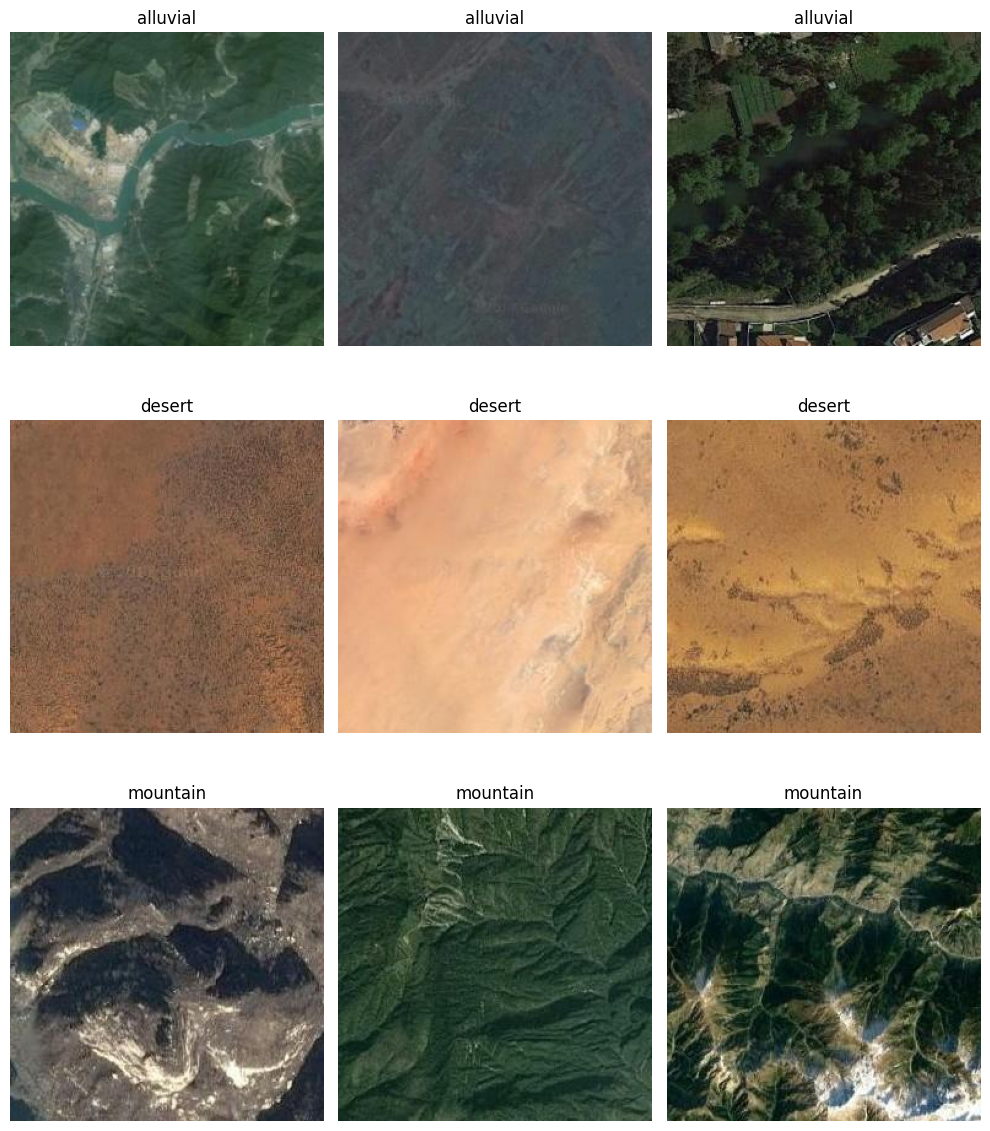

In [17]:
import random

def visualize_three_per_class(root_dir):
    class_folders = [
        d for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ]

    num_classes = len(class_folders)
    images_per_class = 3

    plt.figure(figsize=(10, 4 * num_classes))

    plot_index = 1

    for class_name in class_folders:
        class_path = os.path.join(root_dir, class_name)

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        if len(image_files) == 0:
            continue

        selected = random.sample(
            image_files,
            min(images_per_class, len(image_files))
        )

        for img_name in selected:
            img_path = os.path.join(class_path, img_name)
            img = Image.open(img_path).convert("RGB")

            plt.subplot(num_classes, images_per_class, plot_index)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")

            plot_index += 1

    plt.tight_layout()
    plt.show()

visualize_three_per_class(dataset_folder)



In [25]:
# Generate dataset_audit.csv

record = []
for class_name in os.listdir(dataset_folder):
    class_path = os.path.join(dataset_folder, class_name)
    if os.path.isdir(class_path):
        for filename in os.listdir(class_path):
                if filename.lower().endswith((".jpg", ".jpeg", ".png")):
                    
                    file_path = os.path.join(class_path, filename)

                    record.append({
                        "file_name": filename,
                        "class": class_name,
                        "file_path": file_path,
                        "notes": ""
                    })

In [ ]:
df = pd.DataFrame(record)
df.head()


,file_name,class,file_path,notes
0,alluvial_0.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,
1,alluvial_10.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,
2,alluvial_100.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,
3,alluvial_1000.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,
4,alluvial_1001.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,


In [30]:
def validate_image(file_path):
    try:
        size = os.path.getsize(file_path)

        with Image.open(file_path) as img:
            mode = img.mode
            width, height = img.size

        notes = []

        if size < 10000:
            notes.append("small_file")

        if mode != "RGB":
            notes.append("not_rgb")

        if width < 100 or height < 100:
            notes.append("low_resolution")

        return "; ".join(notes)

    except Exception:
        return "corrupted"

In [31]:
df["notes"] = df["file_path"].apply(validate_image)

In [35]:
df.head()

,file_name,class,file_path,notes
0,alluvial_0.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,
1,alluvial_10.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,small_file
2,alluvial_100.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,
3,alluvial_1000.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,
4,alluvial_1001.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,


In [33]:
df['notes'].value_counts()

notes
              4517
small_file    2994
Name: count, dtype: int64

In [37]:
df.to_csv("soil_type_classification.csv", index=False)

# spliting

In [38]:
df["source_id"] = df["file_name"].apply(
    lambda x: "_".join(x.split("_")[:2])  
)

In [39]:
df.head()

,file_name,class,file_path,notes,source_id
0,alluvial_0.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,,alluvial_0.jpg
1,alluvial_10.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,small_file,alluvial_10.jpg
2,alluvial_100.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,,alluvial_100.jpg
3,alluvial_1000.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,,alluvial_1000.jpg
4,alluvial_1001.jpg,alluvial,C:\Users\debas\OneDrive\Desktop\Final Year Pro...,,alluvial_1001.jpg


In [18]:
from sklearn.model_selection import StratifiedGroupKFold

SEED = 42



In [ ]:
# 1st split :: train -> 70% and temp ->30%
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
X = df["file_path"]
y= df["class"]
groups = df["source_id"]

train_idx, temp_idx = next(
    sgkf.split(X, y, groups)
)

train_df = df.iloc[train_idx]
temp_df = df.iloc[temp_idx]

In [43]:
#2nd split :: test -> 15% and val -> 15% from temp ->305

sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=SEED)

X_temp = temp_df["file_path"]
y_temp = temp_df["class"]
groups_temp = temp_df["source_id"]

val_idx, test_idx = next(
    sgkf2.split(X_temp, y_temp, groups_temp)
)

val_df = temp_df.iloc[val_idx]
test_df = temp_df.iloc[test_idx]

In [44]:
def print_distribution(name, data):
    print(f"\n{name} distribution:")
    print(data["class"].value_counts(normalize=True))

print_distribution("Train", train_df)
print_distribution("Validation", val_df)
print_distribution("Test", test_df)



Train distribution:
class
desert      0.338049
mountain    0.332889
alluvial    0.329061
Name: proportion, dtype: float64

Validation distribution:
class
desert      0.338216
mountain    0.332889
alluvial    0.328895
Name: proportion, dtype: float64

Test distribution:
class
desert      0.337766
mountain    0.332447
alluvial    0.329787
Name: proportion, dtype: float64


In [45]:
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

In [10]:
def create_split_folders(base_output_dir, classes):
    for split in ["train", "val", "test"]:
        for cls in classes:
            path = os.path.join(base_output_dir, split, cls)
            os.makedirs(path, exist_ok=True)

In [19]:
import shutil

def copy_images_from_csv(csv_path, split_name, output_base_dir):
    df = pd.read_csv(csv_path)

    for _, row in df.iterrows():
        src_path = row["file_path"]
        class_name = row["class"]

        dst_path = os.path.join(
            output_base_dir,
            split_name,
            class_name,
            os.path.basename(src_path)
        )

        shutil.copy2(src_path, dst_path)

In [12]:
BASE_OUTPUT = "dataset_split"

df_all = pd.read_csv("soil_type_classification.csv")
classes = df_all["class"].unique()

create_split_folders(BASE_OUTPUT, classes)

copy_images_from_csv("train_split.csv", "train", BASE_OUTPUT)
copy_images_from_csv("val_split.csv", "val", BASE_OUTPUT)
copy_images_from_csv("test_split.csv", "test", BASE_OUTPUT)

print("Dataset split completed.")


Dataset split completed.


# Build Input Pipeline

In [20]:
SPLIT_DATASET = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\Dataset\soil_type_classification\dataset_split"

In [21]:
# resize images to 224 X 224
def resize_images(root_dir,size=(224, 224)):
    total = 0
    resized = 0
    
    for split in ["train", "val", "test"]:
        split_path = os.path.join(root_dir, split)

        if not os.path.isdir(split_path):
            continue

        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)

            if os.path.isdir(class_path):
                for filename in os.listdir(class_path):
                    if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
                        file_path = os.path.join(class_path, filename)
                        total += 1
                    try:
                        with Image.open(file_path) as img:
                            img = img.resize(size)
                            img.save(file_path)
                            resized += 1

                    except Exception as e:
                        print(f"Error resizing {file_path}: {e}")

    print(f"Total images processed: {total}")
    print(f"Total images resized: {resized}")
    

In [15]:
resize_images(SPLIT_DATASET, size=(224, 224))

Total images processed: 7511
Total images resized: 7511


In [22]:
# normalize images
from torchvision import transforms
from torchvision.datasets import ImageFolder

efficientnet_normalize = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [23]:
train_ds = ImageFolder(
    root=os.path.join(SPLIT_DATASET, "train"),
    transform=efficientnet_normalize
)
val_ds = ImageFolder(
    root=os.path.join(SPLIT_DATASET, "val"),
    transform=efficientnet_normalize
)
test_ds = ImageFolder(
    root=os.path.join(SPLIT_DATASET, "test"),
    transform=efficientnet_normalize
)

In [24]:
BATCH_SIZE = 32

In [25]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,          # parallel data loading
    pin_memory=True,        # faster GPU transfer
    prefetch_factor=2,      # prefetch batches per worker
    persistent_workers=True # keep workers alive
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

# Data Augmentation

In [26]:
train_transform = transforms.Compose([
    # horizontal flip
    transforms.RandomHorizontalFlip(p=0.5),

    # small rotation (+15 deg)
    transforms.RandomRotation(degrees=15),

    #  random zoom(0.9 - 1.1)
    transforms.RandomAffine(
        degrees=0,
        scale=(0.9, 1.1)
    ),

    # random brightness/contrast
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),

    # small translation
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),

    transforms.ToTensor(),
])

In [27]:
val_test_transform = transforms.Compose([
    transforms.ToTensor()
])

In [28]:
train_ds = ImageFolder(
    root=os.path.join(SPLIT_DATASET, "train"),
    transform=train_transform
)
val_ds = ImageFolder(
    root=os.path.join(SPLIT_DATASET, "val"),
    transform=val_test_transform
)
test_ds = ImageFolder(
    root=os.path.join(SPLIT_DATASET, "test"),
    transform=val_test_transform
)

# Base Model
------------------
### EficientNetB0

In [29]:
import torch
import torch.nn as nn
from torchvision import models

In [30]:
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
    )

In [31]:
# freeze backbone (feature extractor)
for param in model.features.parameters():
    param.requires_grad = False

In [32]:
NUM_CLASSES = 3
DROPOUT_RATE = 0.3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IN_FEATURES = model.classifier[1].in_features

In [33]:
model.classifier = nn.Sequential(
    nn.Dropout(p = DROPOUT_RATE),
    nn.Linear( IN_FEATURES, NUM_CLASSES)
)

In [36]:
model = model.to(DEVICE)


In [38]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")


Total parameters: 4011391
Trainable parameters: 3843


In [39]:
criterion = torch.nn.CrossEntropyLoss()

In [41]:
import torch.optim as optim

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr = 1e-3
)

In [42]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer = optimizer,
    mode = 'max',
    factor = 0.2,
    patience = 2
)

In [43]:
# EarlyStopping

class EarlyStopping:
    def __init__(self, patience = 5):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.best_weights = None


    def step(self, score, model):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
            self.best_weights = model.state_dict()
        else:
            self.counter += 1

        if self.counter >= self.patience:
            print(f"Early stopping triggered after {self.patience} epochs without improvement.")
            model.load_state_dict(self.best_weights)
            return True
        return False


#### Training

In [44]:
from sklearn.metrics import f1_score

early_stopping = EarlyStopping(patience=5)
EPOCHS = 10

In [45]:
for epoch in range(EPOCHS):
    #train
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0) ##

    #validation
    model.eval()

    val_preds = []
    val_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            outputs = model(images)

            preds = torch.argmax(outputs, dim = 1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
    
    macro_f1 = f1_score(val_labels, val_preds, average="macro")

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss/len(train_ds):.4f} - Val Macro F1: {macro_f1:.4f}")

    #scheduler
    scheduler.step(macro_f1)

    # model checkpointing
    torch.save(model.state_dict(), f"efficientnet_epoch{epoch+1}_f1{macro_f1:.4f}.pth")

    #Early stopping
    if early_stopping.step(macro_f1, model):
        print("Early stopping triggered. Ending training.")
        break

c:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 - Train Loss: 0.4065 - Val Macro F1: 0.9386
Epoch 2/10 - Train Loss: 0.2418 - Val Macro F1: 0.9492
Epoch 3/10 - Train Loss: 0.2131 - Val Macro F1: 0.9465
Epoch 4/10 - Train Loss: 0.1913 - Val Macro F1: 0.9506
Epoch 5/10 - Train Loss: 0.1761 - Val Macro F1: 0.9506
Epoch 6/10 - Train Loss: 0.1797 - Val Macro F1: 0.9547
Epoch 7/10 - Train Loss: 0.1692 - Val Macro F1: 0.9572
Epoch 8/10 - Train Loss: 0.1655 - Val Macro F1: 0.9600
Epoch 9/10 - Train Loss: 0.1754 - Val Macro F1: 0.9533
Epoch 10/10 - Train Loss: 0.1695 - Val Macro F1: 0.9573


In [46]:
model.load_state_dict(torch.load("efficientnet_epoch8_f10.9600.pth"))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [47]:
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import numpy as np


In [48]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

c:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [49]:
macro_f1 = f1_score(all_labels, all_preds, average="macro")
accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Macro F1 Score: {macro_f1:.4f}")


Test Accuracy: 0.9681
Test Macro F1 Score: 0.9681


In [50]:
class_names = test_loader.dataset.classes

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

    alluvial       0.97      0.97      0.97       248
      desert       0.99      0.97      0.98       254
    mountain       0.95      0.97      0.96       250

    accuracy                           0.97       752
   macro avg       0.97      0.97      0.97       752
weighted avg       0.97      0.97      0.97       752



In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

conf_mat = confusion_matrix(all_labels, all_preds)

In [52]:
conf_mat

array([[240,   1,   7],
       [  1, 246,   7],
       [  7,   1, 242]])

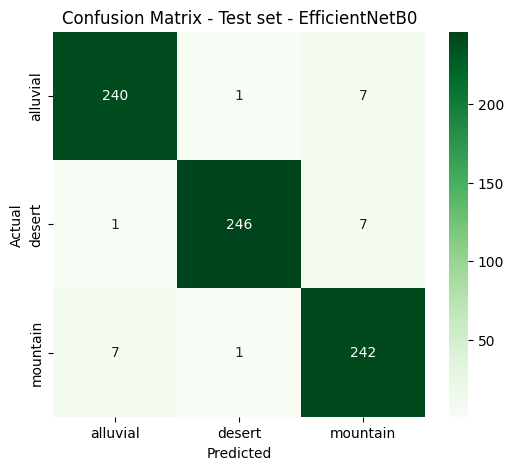

In [53]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - Test set - EfficientNetB0")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [54]:
misclassified = []

model.eval()
idx = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        for i in range(len(labels)):
            if preds[i].cpu() != labels[i]:
                file_path = test_loader.dataset.samples[idx + i][0]

                misclassified.append((
                    file_path,                      # store path
                    images[i].cpu(),                # store tensor
                    preds[i].cpu().item(),
                    labels[i].item()
                ))

        idx += len(labels)


In [55]:
import os

def show_misclassified(samples, class_names, num=6):
    plt.figure(figsize=(12, 6))

    for i in range(min(num, len(samples))):
        file_path, img, pred, true = samples[i]

        img = img.permute(1, 2, 0).numpy()

        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(
            f"{os.path.basename(file_path)}\n"
            f"Pred: {class_names[pred]}\n"
            f"True: {class_names[true]}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5356624..0.07790857].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5253019..1.6291069].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0219197..2.3611329].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.81642264..2.3262744].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2184873].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8506721..1.6988237].


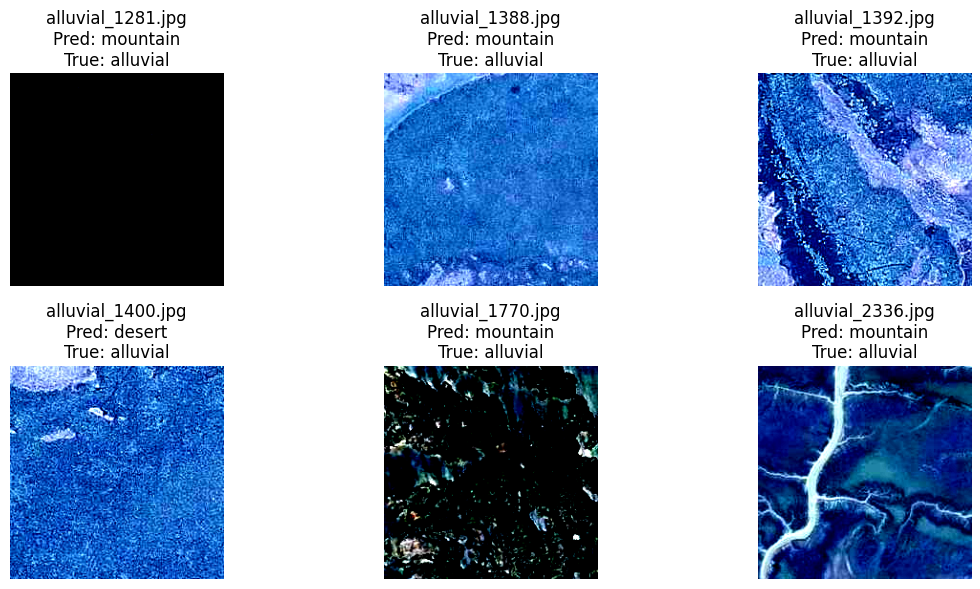

In [56]:
show_misclassified(misclassified, class_names)